In [5]:
#signal explolration - BIDMC PPG and Respiration Dataset
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [6]:
signal_path = r'C:\Users\johna\physiological-signal-AI\raw_data\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv\bidmc_01_Signals.csv'
signals = pd.read_csv(signal_path)
signals.head()

,Time [s],RESP,PLETH,V,AVR,II
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000


In [ ]:
#The columns:
#Time [s] — time in seconds, sampled at 125Hz (every 0.008 seconds)
#PLETH — PPG signal (photoplethysmography) — the pulse wave we care most about
#RESP — respiration signal — breathing
#II — ECG Lead II — heart electrical activity
#V, AVR — other ECG leads

In [7]:
signals.shape

(60001, 6)

In [ ]:
#60,001 rows — at 125Hz that's:
#60,001 / 125 = 480 seconds = 8 minutes of recording, 8 minutes of continuous physiological signals from one ICU patient.

In [11]:
signals.columns = signals.columns.str.strip()
signals.columns.tolist()

['Time [s]', 'RESP', 'PLETH', 'V', 'AVR', 'II']

Text(0.5, 1.0, 'PPG Signal - Patient 01')

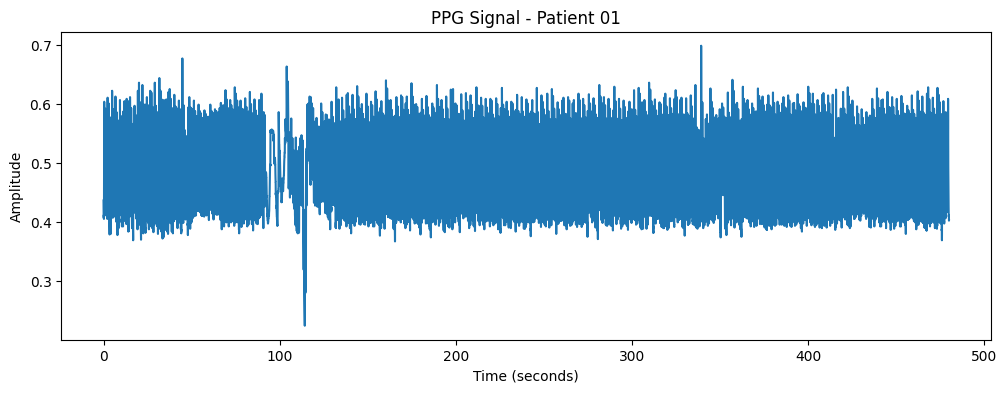

In [12]:
fig, ax = subplots(figsize=(12, 4))
ax.plot(signals['Time [s]'], signals['PLETH'])
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
ax.set_title('PPG Signal - Patient 01')
fig.savefig('PPG Signal - Patient 01',dpi=152)

In [13]:
#The repeating peaks — each peak is one heartbeat. The PPG sensor detects blood volume changes in the fingertip with every pulse.
#You can see roughly 1 peak per second — consistent with a normal heart rate of 60-80 bpm.
#The dip around 100-120 seconds — signal drops suddenly then recovers. This is likely a motion artifact — the patient moved their finger,
#temporarily disrupting the sensor contact. This is exactly the kind of noise you'll need to handle in your research.
#The overall pattern — relatively stable signal across 8 minutes with consistent pulse waves.

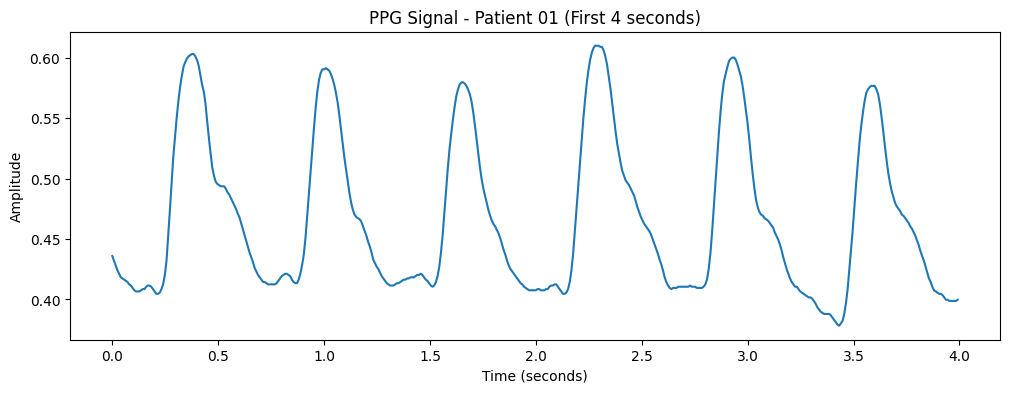

In [20]:
fig, ax = subplots(figsize=(12, 4))
ax.plot(signals['Time [s]'][:500], signals['PLETH'][:500])
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
ax.set_title('PPG Signal - Patient 01 (First 4 seconds)')
fig.savefig(' PPG Signal - Patient 01 (First 4 seconds)', dpi=152)

In [ ]:
#What each wave represents:
#Each complete wave from valley to valley is one heartbeat — about 0.7 seconds between peaks, which means roughly 85 beats per minute for this patient.
#Each wave has a shape:
#Rising slope — heart contracts, blood rushes to fingertip
#Peak — maximum blood volume
#Falling slope — heart relaxes, blood flows back
#Small notch — the dicrotic notch, caused by the aortic valve closing
#Valley — minimum blood volume before next beat
#This wave shape is called the PPG waveform morphology. 
#In research, features extracted from this shape — peak height, rise time, fall time, area under the curve — will be inputs to the model.

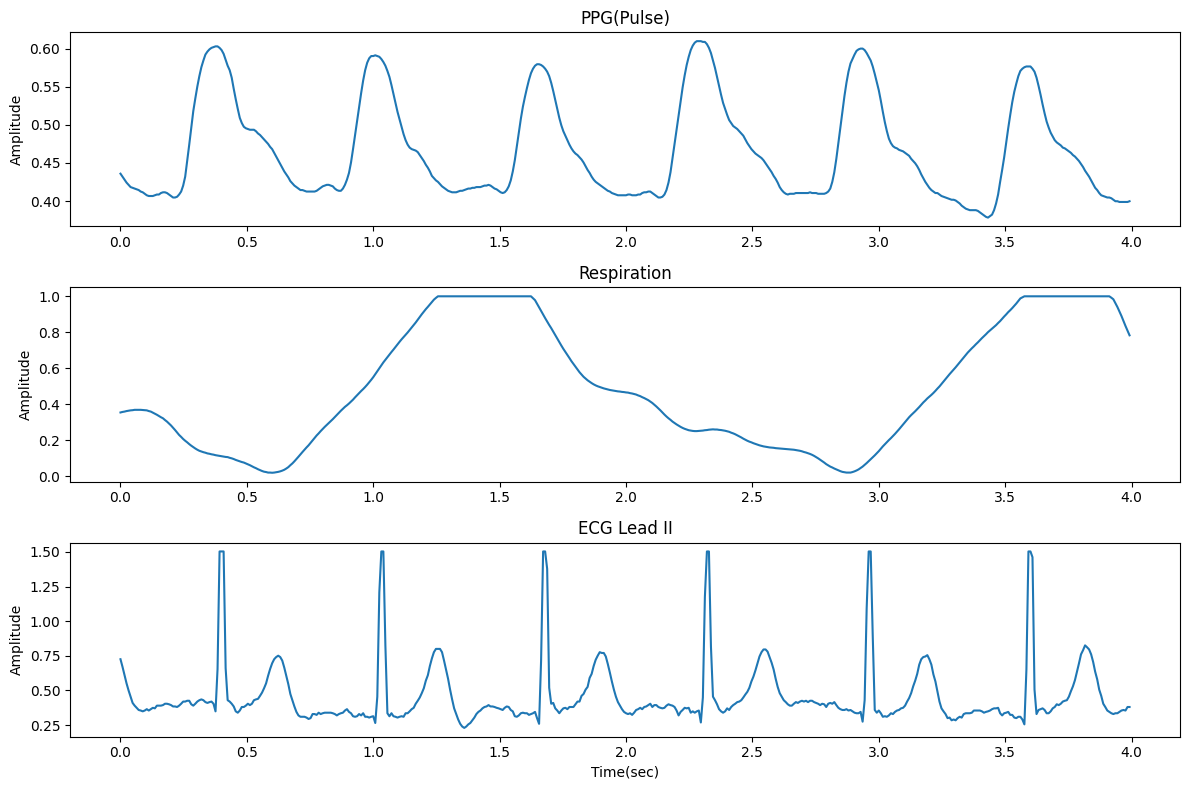

In [27]:
# plot all three main signals together:
fig,axes = subplots(3,1, figsize=(12,8))
axes[0].plot(signals['Time [s]'] [0:500], signals['PLETH'] [:500])
axes[0].set_title('PPG(Pulse)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(signals['Time [s]'] [0:500], signals['RESP'] [:500])
axes[1].set_title('Respiration')
axes[1].set_ylabel('Amplitude')

axes[2].plot(signals['Time [s]'] [0:500], signals['II'] [:500])
axes[2].set_title('ECG Lead II')
axes[2].set_ylabel('Amplitude')

axes[2].set_xlabel('Time(sec)')
fig.tight_layout()
fig.savefig('All signals together', dpi=152)

In [ ]:
#multimodal physiological signals from a human patient.
#PPG (top) — clear pulse waves, one per heartbeat, about 85 bpm. Smooth rounded shape.
#Respiration (middle) — much slower wave, one complete breath cycle takes about 3-4 seconds — roughly 15-20 breaths per minute.
#Notice how it's much slower than the heartbeat.
#ECG Lead II (bottom) — the sharp spikes are the R-peaks — the most recognizable feature of an ECG. Each spike is the main electrical activation
#of the heart ventricles. Between spikes you can see the smaller P and T waves.
#The relationship between all three:
#Every ECG spike triggers a PPG wave — the electrical signal causes the mechanical pumping
#The respiration wave modulates the PPG amplitude — you can see the PPG peaks vary slightly in height following the breathing rhythm
#This coupling between signals is called cardiorespiratory coupling — a key research area